<a href="https://colab.research.google.com/github/MorningHero92/S_Vision/blob/main/Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Installing dependencies

In [7]:
# We need to install ipympl backend for matplotlib to work correctly in Colab
# After this, session should be restarted for changes to take effect

!pip install ipympl
from google.colab import output
output.enable_custom_widget_manager()

print("Настройка завершена!")

Настройка завершена!


In [1]:
# setting proper backend for matplotlib

%matplotlib ipympl
import matplotlib.pyplot as plt

# Installing ultralytics

!uv pip install ultralytics
import ultralytics
ultralytics.checks()

# Cloning git

!git clone https://github.com/MorningHero92/S_Vision.git

#Setting paths

import sys
sys.path.append('/content/S_Vision/src/traffic')

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 21.3/107.7 GB disk)
Cloning into 'S_Vision'...
remote: Enumerating objects: 322, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 322 (delta 58), reused 0 (delta 0), pack-reused 192 (from 2)
Receiving objects: 100% (322/322), 99.19 KiB | 2.07 MiB/s, done.
Resolving deltas: 100% (121/121), done.


2. Git pull in case GIT was updated during session

In [ ]:
#In case we changed something in GIT ---

!git -C /content/S_Vision pull

remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.68 KiB | 429.00 KiB/s, done.
From https://github.com/MorningHero92/S_Vision
   e116a1a..954c070  main       -> origin/main
Updating e116a1a..954c070
Fast-forward
 src/traffic/tracking/tracker.py | 11 ++++++-----
 1 file changed, 6 insertions(+), 5 deletions(-)


3. Main program

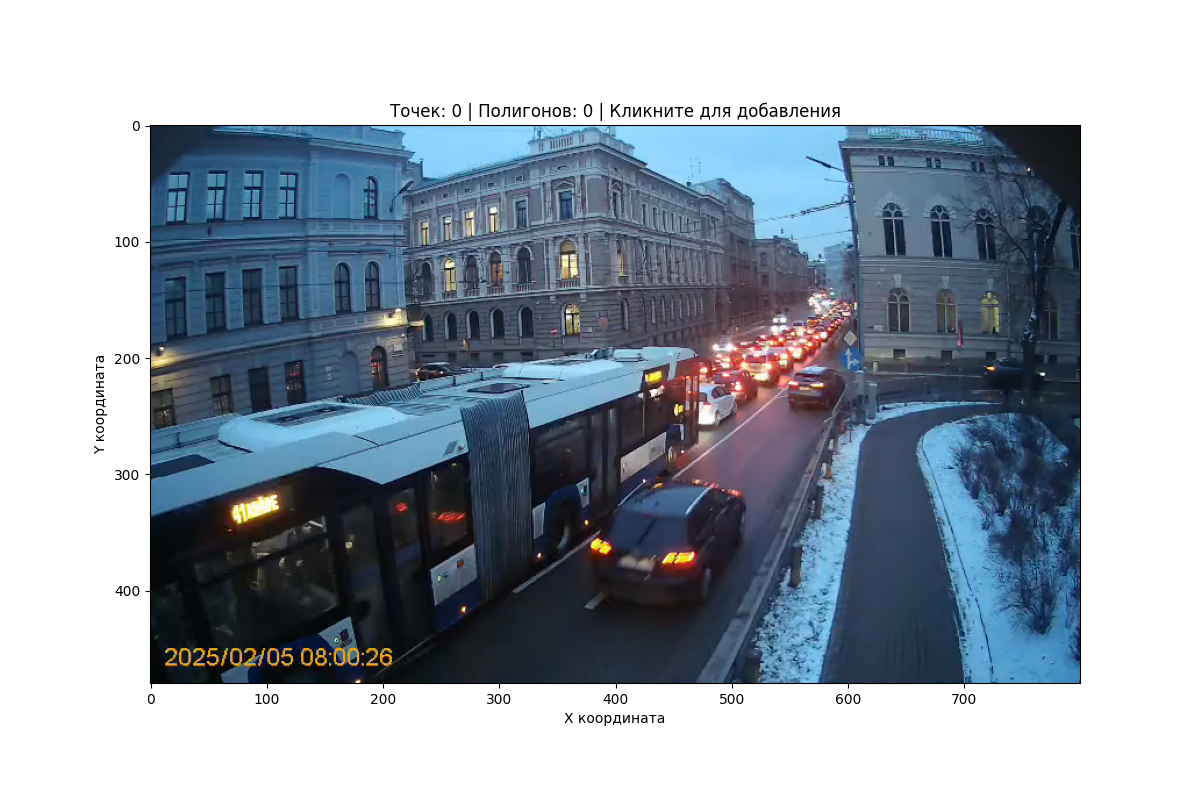

'run_tracking(\n    model_path=model_path,\n    video_path=video_path,\n    output_path=output_path,\n    tracker_yaml=tracker_yaml,\n    **model_settings\n)'

✅ Точка 1: (93, 19)
✅ Точка 2: (243, 176)
✅ Точка 3: (324, 73)
🗑 Всё очищено
✅ Точка 1: (324, 73)
✅ Точка 2: (544, 189)
✅ Точка 3: (310, 276)
✅ Полигон 1 завершен!


In [8]:
import cv2
from ultralytics import YOLO

from tracking.tracker import run_tracking
from tracking.settings import get_tracker_yaml
from drawing.drawing_tools import InteractiveZoneDrawer

model_path = "yolo26m.pt"
video_path = "/content/drive/MyDrive/Machine_Vision/Source_videos/Vansu_Tilts_End.mp4"
output_path = "/content/drive/MyDrive/Machine_Vision/Output_videos/Vansu_Tilts_End_out.mp4"
# tracker_yaml = "/content/drive/MyDrive/Machine_Vision/YAMLs/botsort.yaml"

model_settings = dict(
    conf=0.3,
    iou=0.5,
    classes=[2, 3, 5, 7],
    batch=1,
    vid_stride=1
)

tracker_settings = dict(
    tracker_type="botsort", # (str) Tracker backend: botsort|bytetrack; choose botsort to enable BoT-SORT features
    track_high_thresh=0.25, # (float) | Default = 0.25 | First-stage match threshold; raise for cleaner tracks, lower to keep more
    track_low_thresh=0.1, # (float) | Default = 0.1 | Second-stage threshold for low-score matches; balances recovery vs drift
    new_track_thresh=0.25, # (float) | Default = 0.25 | Start a new track if no match ≥ this; higher reduces false tracks
    track_buffer=30, # (int) | Default = 30 | Frames to keep lost tracks alive; higher handles occlusion, increases ID switches risk
    match_thresh=0.8, # (float) | Default = 0.8 | Association similarity threshold (IoU/cost); tune with detector quality
    fuse_score=True, # (bool) | Default = True | Fuse detection score with motion/IoU for matching; stabilizes weak detections


    # BoT-SORT specifics
    gmc_method="sparseOptFlow", # (str) Global motion compensation: sparseOptFlow|orb|sift|ecc|none; helps moving camera scenes

    # ReID model related thresh
    proximity_thresh=0.5, # (float) | Default = 0.5 | Min IoU to consider tracks proximate for ReID; higher is stricter
    appearance_thresh=0.8, # (float) | Default = 0.8 | Min appearance similarity for ReID; raise to avoid identity swaps
    with_reid=True, # (bool) | Default = True | Enable ReID model use; needs extra model and compute
    model="auto" # (str) ReID model name/path; "auto" uses detector features if available
)

tracker_yaml = get_tracker_yaml(**tracker_settings)

drawer = InteractiveZoneDrawer(video_path)
zones = drawer.get_polygons()

"""run_tracking(
    model_path=model_path,
    video_path=video_path,
    output_path=output_path,
    tracker_yaml=tracker_yaml,
    **model_settings
)"""